# HW 03

## 1a
Read up on network configuration model!

## 1b


In [29]:
import numpy as np
import networkx as nx

def configuration_model(degrees, return_graph = False):
    
    # Molloy–Reed configuration model from reading.
    # degrees: list/array of nonnegative integers, node i has degree degrees[i]
    # return_graph=False -> return edge list; True -> return nx.MultiGraph
    
    # basic checks
    deg = list(degrees)
    if any((d < 0) or (int(d) != d) for d in deg):
        raise ValueError("Degrees must be nonnegative integers")
    if sum(deg) % 2 != 0:
        raise ValueError("Sum of degrees must be even")

    # expand degrees into a stub list of node ids
    stubs = []
    for i, d in enumerate(deg):
        for _ in range(int(d)):
            stubs.append(i)

    # random permutation and sequential pairing
    stubs = np.array(stubs, dtype = int)
    np.random.shuffle(stubs)
    edges = []
    for i in range(0, len(stubs), 2):
        u = int(stubs[i])
        v = int(stubs[i + 1])
        edges.append((u, v))

    # graph return
    if return_graph:
        G = nx.MultiGraph()
        G.add_nodes_from(range(len(deg)))  # keep isolated nodes
        G.add_edges_from(edges)
        return G
    else:
        return edges


In [30]:
deg = [3, 2, 1, 0, 2, 2]
E = configuration_model(deg)                        # edge list
G = configuration_model(deg, return_graph = True)   # MultiGraph


# 1c

In [31]:
import numpy as np
import pandas as pd
import networkx as nx

# guide code verbatim
def power_law(n: int, minval: int, maxval: int, alpha: float, seed: int | None = None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)
    u = np.random.random(n)
    if alpha == -1:
        return np.round(np.exp(np.log(minval - 0.5) + u * (np.log(maxval + 0.5) - np.log(minval - 0.5)))).astype(int)
    else:
        a = (minval - 0.5) ** (1 + alpha)
        b = (maxval + 0.5) ** (1 + alpha)
        return np.round((a + u * (b - a)) ** (1 / (1 + alpha))).astype(int)

# plain configuration model: expand stubs -> shuffle -> pair
def configuration_model(degrees, return_graph=False):
    d = list(degrees)
    stubs = []
    for i, k in enumerate(d):
        for _ in range(int(k)):
            stubs.append(i)
    stubs = np.array(stubs, dtype=int)
    np.random.shuffle(stubs)
    edges = []
    for i in range(0, len(stubs), 2):
        u = int(stubs[i])
        v = int(stubs[i+1])
        edges.append((u, v))
    if return_graph:
        G = nx.MultiGraph()
        G.add_nodes_from(range(len(d)))
        G.add_edges_from(edges)
        return G
    return edges

# parameters 
N = 1000
minval = 1
maxval = N - 1
alpha = -2.5

# one degree sequence
deg = power_law(N, minval, maxval, alpha, seed=42)
if deg.sum() % 2 == 1:                       # make even by adding 1 to a random node
    deg[np.random.randint(0, N)] += 1

# 1000 realizations: fractions of self-loops and multi-edges
T = 1000
loop_frac = []
multi_frac = []

for _ in range(T):
    E = configuration_model(deg)             # edge list
    m = len(E)

    # self-loops
    loops = 0
    for u, v in E:
        if u == v:
            loops += 1

    # multi-edges beyond one copy per unordered pair
    counts = {}
    for u, v in E:
        if u <= v:
            key = (u, v)
        else:
            key = (v, u)
        if key in counts:
            counts[key] += 1
        else:
            counts[key] = 1
    multi_extra = 0
    for key in counts:
        c = counts[key]
        if c > 1:
            multi_extra += (c - 1)

    loop_frac.append(loops / m)
    multi_frac.append(multi_extra / m)

print("Configuration model over 1000 runs")
print("avg self-loop fraction:", float(np.mean(loop_frac)))
print("avg multi-edge fraction:", float(np.mean(multi_frac)))

# compare to budapest_connectome 
df = pd.read_csv("../../data/buda-edge-list.csv", sep = ";")
edges_b = list(zip(df["id node1"].astype(int), df["id node2"].astype(int)))
m_b = len(edges_b)

loops_b = 0
for u, v in edges_b:
    if u == v:
        loops_b += 1

counts_b = {}
for u, v in edges_b:
    if u <= v:
        key = (u, v)
    else:
        key = (v, u)
    if key in counts_b:
        counts_b[key] += 1
    else:
        counts_b[key] = 1

multi_extra_b = 0
for key in counts_b:
    c = counts_b[key]
    if c > 1:
        multi_extra_b += (c - 1)

print("\nbudapest_connectome")
print("self-loop fraction:", loops_b / m_b)
print("multi-edge fraction:", multi_extra_b / m_b)


Configuration model over 1000 runs
avg self-loop fraction: 0.006315989847715736
avg multi-edge fraction: 0.013234771573604061

budapest_connectome
self-loop fraction: 0.011
multi-edge fraction: 0.0


# 1d

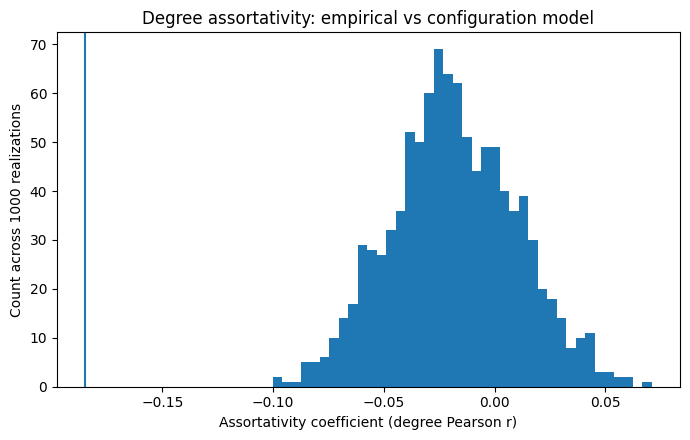

Empirical assortativity: -0.1847977508348608
Ensemble mean: -0.01832278241762666
Ensemble std: 0.028346988940829904


In [32]:
# assortativity vs configuration model (uses my configuration_model)
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# (i) empirical MultiGraph from CSV
df = pd.read_csv("../../data/buda-edge-list.csv", sep = ";")
edges = list(zip(df["id node1"].astype(int), df["id node2"].astype(int)))
G_emp = nx.MultiGraph()
G_emp.add_edges_from(edges)

# degree sequence in the order of nodes we’ll use
nodes = list(G_emp.nodes())
deg = [G_emp.degree(u) for u in nodes]

# (iii) empirical assortativity
r_emp = nx.degree_pearson_correlation_coefficient(G_emp)

# (ii) 1,000 realizations using my configuration_model
T = 1000
rs = []
for _ in range(T):
    Gsyn = configuration_model(deg, return_graph = True)
    rs.append(nx.degree_pearson_correlation_coefficient(Gsyn))

# plot: histogram + vertical line w labels
plt.figure(figsize = (7, 4.5))
plt.hist(rs, bins = 40)
plt.axvline(r_emp)
plt.title("Degree assortativity: empirical vs configuration model")
plt.xlabel("Assortativity coefficient (degree Pearson r)")
plt.ylabel("Count across 1000 realizations")
plt.tight_layout()
plt.show()

print("Empirical assortativity:", float(r_emp))
print("Ensemble mean:", float(np.mean(rs)))
print("Ensemble std:", float(np.std(rs, ddof = 1)))


# 2a

In [33]:
# built-in Florentine families graph
G = nx.florentine_families_graph()

# degree centrality
deg = nx.degree_centrality(G)
deg_rows = [(n, round(deg[n], 3)) for n in G.nodes()]
deg_rows = sorted(deg_rows, key = lambda x: x[1], reverse = True)

# harmonic centrality
harm = nx.harmonic_centrality(G)
harm_rows = [(n, round(harm[n], 3)) for n in G.nodes()]
harm_rows = sorted(harm_rows, key = lambda x: x[1], reverse = True)

# eigenvector centrality
eig = nx.eigenvector_centrality_numpy(G)
eig_rows = [(n, round(eig[n], 3)) for n in G.nodes()]
eig_rows = sorted(eig_rows, key = lambda x: x[1], reverse = True)

# betweenness centrality
bet = nx.betweenness_centrality(G, normalized = True, endpoints = False)
bet_rows = [(n, round(bet[n], 3)) for n in G.nodes()]
bet_rows = sorted(bet_rows, key = lambda x: x[1], reverse = True)

import polars as pl

# Combine all centrality measures into one DataFrame
df = pl.DataFrame({
    "Family": [r[0] for r in deg_rows],
    "Degree": [r[1] for r in deg_rows],
    "Harmonic": [r[1] for r in harm_rows],
    "Eigenvector": [r[1] for r in eig_rows],
    "Betweenness": [r[1] for r in bet_rows],
})

print(df)



shape: (15, 5)
┌──────────────┬────────┬──────────┬─────────────┬─────────────┐
│ Family       ┆ Degree ┆ Harmonic ┆ Eigenvector ┆ Betweenness │
│ ---          ┆ ---    ┆ ---      ┆ ---         ┆ ---         │
│ str          ┆ f64    ┆ f64      ┆ f64         ┆ f64         │
╞══════════════╪════════╪══════════╪═════════════╪═════════════╡
│ Medici       ┆ 0.429  ┆ 9.5      ┆ 0.43        ┆ 0.522       │
│ Strozzi      ┆ 0.286  ┆ 8.083    ┆ 0.356       ┆ 0.255       │
│ Guadagni     ┆ 0.286  ┆ 8.0      ┆ 0.342       ┆ 0.212       │
│ Castellani   ┆ 0.214  ┆ 7.833    ┆ 0.326       ┆ 0.143       │
│ Peruzzi      ┆ 0.214  ┆ 7.833    ┆ 0.289       ┆ 0.114       │
│ …            ┆ …      ┆ …        ┆ …           ┆ …           │
│ Salviati     ┆ 0.143  ┆ 6.583    ┆ 0.146       ┆ 0.022       │
│ Acciaiuoli   ┆ 0.071  ┆ 5.917    ┆ 0.132       ┆ 0.0         │
│ Pazzi        ┆ 0.071  ┆ 5.367    ┆ 0.089       ┆ 0.0         │
│ Ginori       ┆ 0.071  ┆ 5.333    ┆ 0.075       ┆ 0.0         │
│ Lamberte

The centrality results back Padgett and Ansell: Medici sits first on degree, eigenvector, betweenness, and harmonic, which means they had the most ties, were linked to other well connected families, controlled many shortest paths, and could reach others quickly. For the runner-up, it depends on what we value. Strozzi looks second by degree and eigenvector, signaling a strong hub tied to other prominent houses. Guadagni ranks second by betweenness and harmonic, pointing to a family with good brokerage power and wide reach across the network.

# 2b

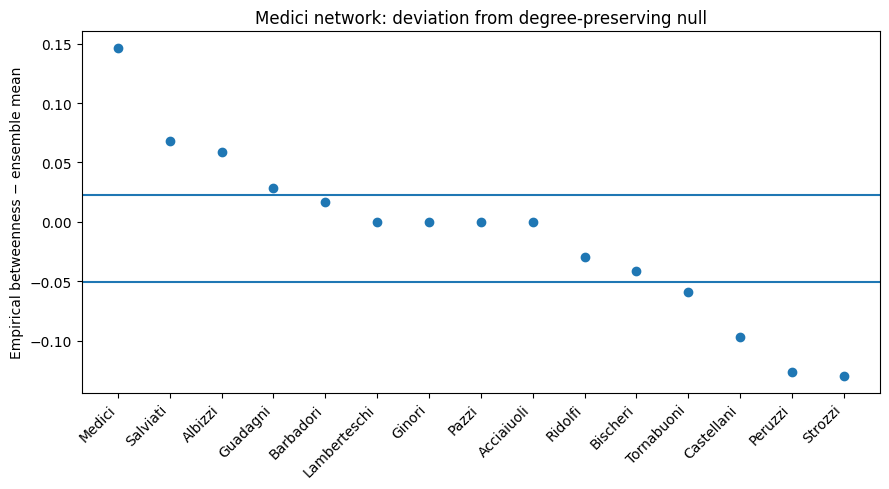

Medici delta (empirical − mean): 0.14663260073260104
Top 5 by positive delta: ['Medici', 'Salviati', 'Albizzi', 'Guadagni', 'Barbadori']
25% and 75% quantile lines: -0.050521245421245614 0.022778479853479507


In [34]:
# empirical Medici network
G = nx.florentine_families_graph()
nodes = list(G.nodes())
n = len(nodes)

# empirical betweenness
b_emp_d = nx.betweenness_centrality(G, normalized=True, endpoints=False)
b_emp = np.array([b_emp_d[u] for u in nodes])

# degree sequence in the order we will use to label 0..n-1 in our generator
deg = [G.degree(u) for u in nodes]

# betweenness samples per node
T = 1000
samples = np.zeros((T, n))
for t in range(T):
    Gsyn = configuration_model(deg, return_graph=True)  # MY function
    b_syn_d = nx.betweenness_centrality(Gsyn, normalized=True, endpoints=False)
    for i in range(n):
        samples[t, i] = b_syn_d[i]  # generator labels nodes 0..n-1

# empirical minus ensemble mean
b_mean = samples.mean(axis=0)
delta = b_emp - b_mean

# deltas per node, sorted; add 25% and 75% quantile lines
order = np.argsort(delta)[::-1]
x = np.arange(n)
plt.figure(figsize=(9, 5))
plt.scatter(x, delta[order])
q25 = np.quantile(delta, 0.25)
q75 = np.quantile(delta, 0.75)
plt.axhline(q25)
plt.axhline(q75)
plt.xticks(x, [nodes[i] for i in order], rotation=45, ha="right")
plt.ylabel("Empirical betweenness − ensemble mean")
plt.title("Medici network: deviation from degree-preserving null")
plt.tight_layout()
plt.show()

# quick text to help write-up
medici_idx = nodes.index("Medici")
print("Medici delta (empirical − mean):", float(delta[medici_idx]))
print("Top 5 by positive delta:", [nodes[i] for i in order[:5]])
print("25% and 75% quantile lines:", float(q25), float(q75))


If Medici’s delta is well above the 75% line and near the top of the list, their high betweenness is not just a by-product of degree; it reflects brokerage across factions, consistent with Padgett & Ansell’s story. This doesn’t change the conclusion from part (a): Medici remain structurally dominant. If another house (often Guadagni) also shows a large positive delta, note their brokerage role as a strong runner-up.